# Exploratory Data Analysis — Face Occlusion Dataset

In [3]:
import sys
sys.path.insert(0, "../../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

TRAIN_CSV = "../../../dataset/DataChallenge2026/occlusion_datasets/train.csv"
IMG_ROOT  = "../../../dataset/crops/Crop_224_5fp_100K"

df = pd.read_csv(TRAIN_CSV)
df["gender_label"] = df["gender"].map({0.0: "Female", 1.0: "Male"})
print(f"Total samples: {len(df)}")
df.head()

Total samples: 100000


,filename,FaceOcclusion,gender,gender_label
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0,Male
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0,Male
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0,Female
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0,Male
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0,Male


## 1. Gender Distribution

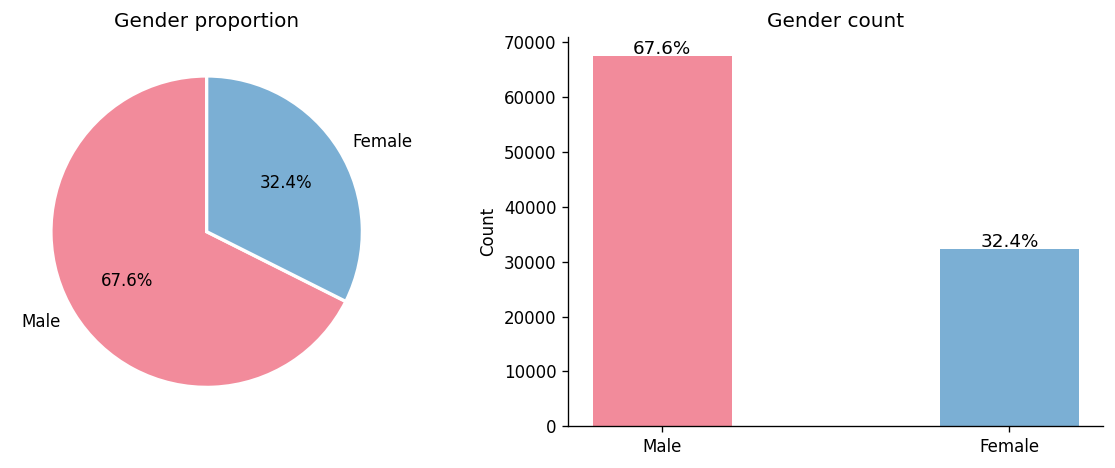

gender_label
Male      67600
Female    32400


In [4]:
counts = df["gender_label"].value_counts()
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["#f28b9b", "#7bafd4"], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[0].set_title("Gender proportion")

# Bar
bars = axes[1].bar(counts.index, counts.values, color=["#f28b9b", "#7bafd4"], width=0.4)
for bar, pct in zip(bars, pcts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f"{pct:.1f}%", ha="center", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_title("Gender count")

plt.tight_layout()
plt.show()
print(counts.to_string())

## 2. Occlusion Score Distribution

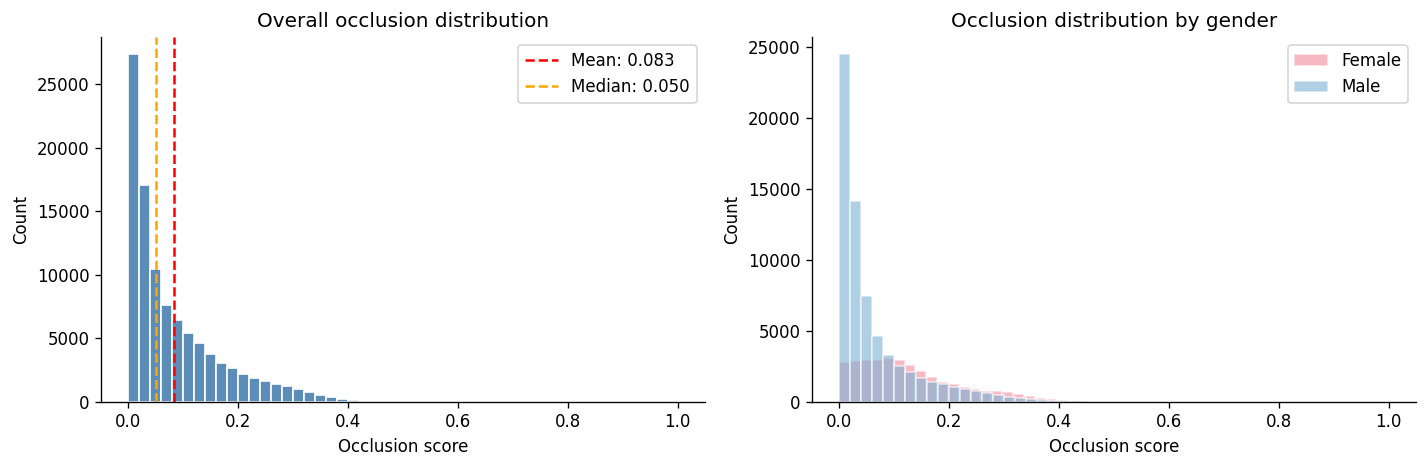

                count    mean     std  min     25%     50%     75%     max
gender_label                                                              
Female        32400.0  0.1285  0.0939  0.0  0.0557  0.1089  0.1815  0.9878
Male          67600.0  0.0608  0.0733  0.0  0.0127  0.0315  0.0797  1.0000


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
axes[0].hist(df["FaceOcclusion"], bins=50, color="#5b8db8", edgecolor="white")
axes[0].set_xlabel("Occlusion score")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall occlusion distribution")
axes[0].axvline(df["FaceOcclusion"].mean(), color="red", linestyle="--", label=f'Mean: {df["FaceOcclusion"].mean():.3f}')
axes[0].axvline(df["FaceOcclusion"].median(), color="orange", linestyle="--", label=f'Median: {df["FaceOcclusion"].median():.3f}')
axes[0].legend()

# By gender
for label, color in [("Female", "#f28b9b"), ("Male", "#7bafd4")]:
    subset = df[df["gender_label"] == label]["FaceOcclusion"]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, edgecolor="white", label=label)
axes[1].set_xlabel("Occlusion score")
axes[1].set_ylabel("Count")
axes[1].set_title("Occlusion distribution by gender")
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby("gender_label")["FaceOcclusion"].describe().round(4))

## 3. Occlusion Bucket Breakdown

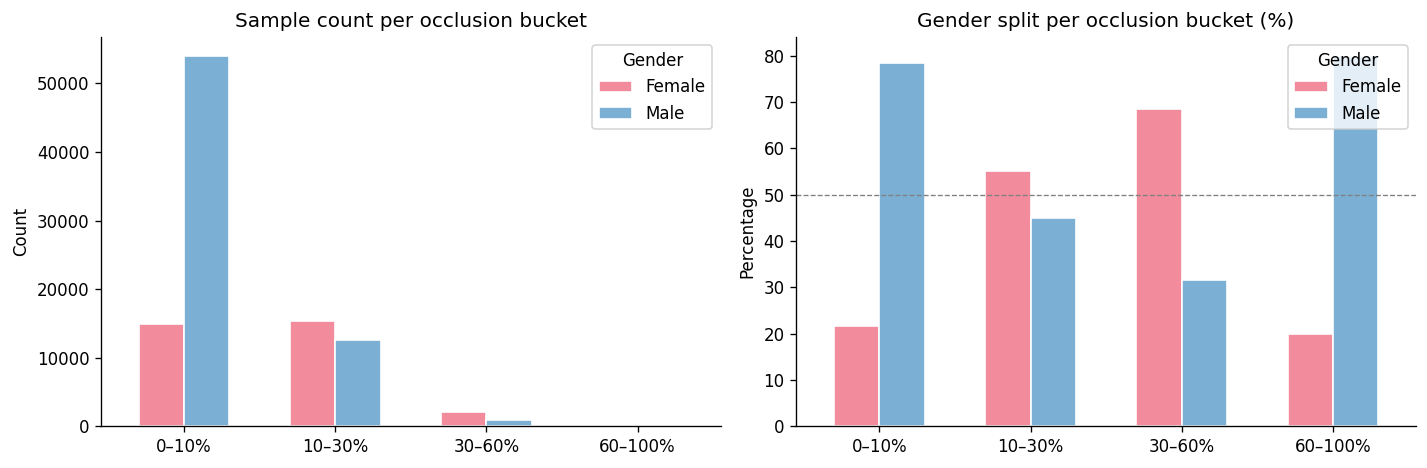

gender_label  Female   Male
bucket                     
0–10%          14884  54045
10–30%         15371  12559
30–60%          2143    988
60–100%            2      8


In [6]:
bins   = [0, 0.1, 0.3, 0.6, 1.0]
labels = ["0-10%", "10-30%", "30-60%", "60-100%"]
df["bucket"] = pd.cut(df["FaceOcclusion"], bins=bins, labels=labels, include_lowest=True)

bucket_gender = df.groupby(["bucket", "gender_label"], observed=True).size().unstack(fill_value=0)
bucket_pct    = bucket_gender.div(bucket_gender.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bucket_gender.plot(kind="bar", ax=axes[0], color=["#f28b9b", "#7bafd4"],
                   edgecolor="white", width=0.6)
axes[0].set_title("Sample count per occlusion bucket")
axes[0].set_xlabel("")
axes[0].set_xticklabels(labels, rotation=0)
axes[0].set_ylabel("Count")
axes[0].legend(title="Gender")

bucket_pct.plot(kind="bar", ax=axes[1], color=["#f28b9b", "#7bafd4"],
                edgecolor="white", width=0.6)
axes[1].set_title("Gender split per occlusion bucket (%)")
axes[1].set_xlabel("")
axes[1].set_xticklabels(labels, rotation=0)
axes[1].set_ylabel("Percentage")
axes[1].axhline(50, color="gray", linestyle="--", linewidth=0.8)
axes[1].legend(title="Gender")

plt.tight_layout()
plt.show()
print(bucket_gender)

## 4. Sample Images per Bucket

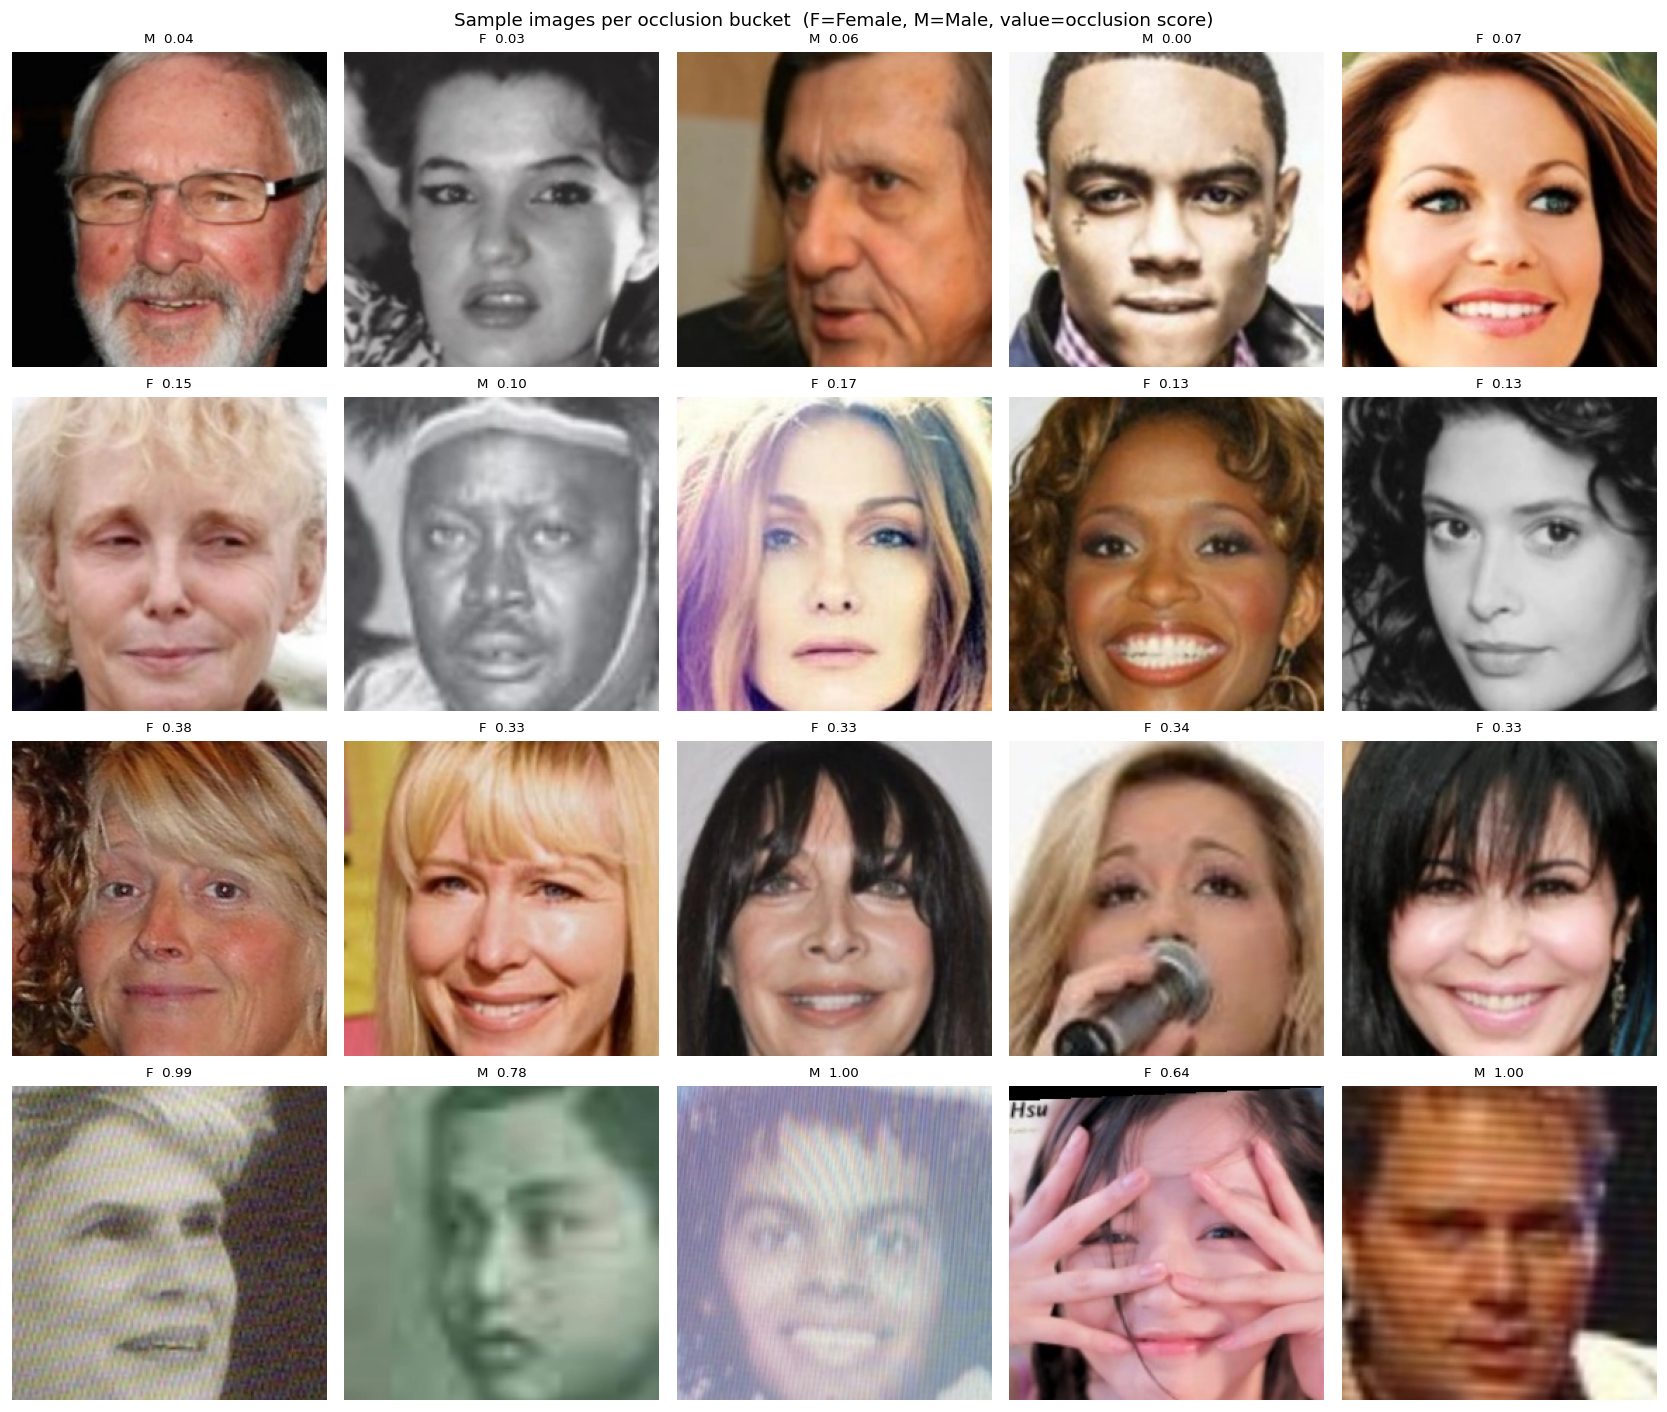

In [7]:
n_cols = 5
fig, axes = plt.subplots(len(labels), n_cols, figsize=(14, 3 * len(labels)))

for row_idx, bucket in enumerate(labels):
    samples = df[df["bucket"] == bucket].sample(n=n_cols, random_state=42)
    for col_idx, (_, sample) in enumerate(samples.iterrows()):
        img_path = os.path.join(IMG_ROOT, sample["filename"])
        img = Image.open(img_path).convert("RGB")
        ax = axes[row_idx][col_idx]
        ax.imshow(img)
        ax.set_title(f'{sample["gender_label"][0]}  {sample["FaceOcclusion"]:.2f}', fontsize=8)
        ax.axis("off")
    axes[row_idx][0].set_ylabel(bucket, fontsize=10, rotation=90, labelpad=40, va="center")

plt.suptitle("Sample images per occlusion bucket  (F=Female, M=Male, value=occlusion score)", fontsize=11)
plt.tight_layout()
plt.show()